<h2>Trabalho relacionado a AP3 - Robótica </h2>

<p><strong>Juan de Souza Holanda, 557239</strong></p>
<p><strong>Matheus de Castro Vieira, 553384</strong></p>

importações

In [ ]:
!pip install "numpy<2.0" # roboticstoolbox não suporta novas versoõs do Numpy

In [ ]:
!pip install roboticstoolbox-python spatialmath-python # biblioteca equivalente ao Robotics Toolbox para o MATLAB

  Using cached roboticstoolbox_python-1.1.1.tar.gz (1.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
from google.colab import files
from roboticstoolbox import DHRobot, RevoluteDH

Definindo os parâmetros e constantes

In [ ]:
#comprimentos elos (m)
L1 = 4.0
L2 = 3.0
L3 = 2.0

# Configuração da Simulação
tempo_total = 5.0
dt = 0.1
total_passos = int(tempo_total / dt)

# Condições Iniciais:
# - angulos das juntas [theta1, theta2, theta3] (rads)
angulos_juntas = np.deg2rad([10.0, 20.0, 30.0])

# - velocidade
# [vx, vy, v_ang_omega]
cmd_velocidade_cartesiana = np.array([
    [ 0.2],
    [-0.3],
    [-0.2]
])

# - força
# Vetor: [FX, FY, MZ]
cmd_forca_momento = np.array([
    [1.0],
    [2.0],
    [3.0]
])

# Listas para armazenar o histórico dos dados (para gerar os gráficos depois)
hist_tempo = []
hist_angulos = []          # Posição das juntas (theta)
hist_velocidade_juntas = [] # Velocidade das juntas (theta')
hist_posicao_cartesiana = [] # Posição da ponta do robô (x, y, phi)
hist_jacobiano = []        # Armazena o Jacobiano
hist_det_jacobiano = []    # Determinante matriz J
hist_torques = []          # Torques necessários nas juntas

loop

In [ ]:
for i in range(total_passos):
    tempo_atual = i * dt

    th1 = angulos_juntas[0]
    th2 = angulos_juntas[1]
    th3 = angulos_juntas[2]

    #calculando senos e cossenos
    s1 = np.sin(th1)
    c1 = np.cos(th1)
    s12 = np.sin(th1 + th2)
    c12 = np.cos(th1 + th2)
    s123 = np.sin(th1 + th2 + th3)
    c123 = np.cos(th1 + th2 + th3)

    # calcular jacobiano

    # Dx/Dtheta
    j11 = -L1*s1 - L2*s12 - L3*s123
    j12 =        - L2*s12 - L3*s123
    j13 =                 - L3*s123

    # Dy/Dtheta
    j21 =  L1*c1 + L2*c12 + L3*c123
    j22 =          L2*c12 + L3*c123
    j23 =                   L3*c123

    # Derivada da rotação (phi)
    j31 = 1
    j32 = 1
    j33 = 1

    # matriz J
    Jacobiano = np.array([
        [j11, j12, j13],
        [j21, j22, j23],
        [j31, j32, j33]
    ])

    hist_jacobiano.append(Jacobiano.copy())

    # - cinemática inversa da velocidade

    # verificando se há singularidade
    det_J = np.linalg.det(Jacobiano)

    try:
        Jacobiano_inv = np.linalg.inv(Jacobiano)

        velocidade_juntas = Jacobiano_inv @ cmd_velocidade_cartesiana
    except np.linalg.LinAlgError:
        print(f"Erro: Singularidade atingida no tempo {tempo_atual:.2f}s (Determinante é zero)")
        velocidade_juntas = np.zeros((3,1))

    # - estática inversa
    torques = Jacobiano.T @ cmd_forca_momento

    # - cinemática direta
    pos_x = L1*c1 + L2*c12 + L3*c123
    pos_y = L1*s1 + L2*s12 + L3*s123
    pos_phi = th1 + th2 + th3

    hist_tempo.append(tempo_atual)
    hist_angulos.append(angulos_juntas.copy())
    hist_velocidade_juntas.append(velocidade_juntas.flatten())
    hist_posicao_cartesiana.append([pos_x, pos_y, pos_phi])
    hist_det_jacobiano.append(det_J)
    hist_torques.append(torques.flatten())

    # - Atualizar ângulos para próxima iteração
    angulos_juntas = angulos_juntas + (velocidade_juntas.flatten() * dt)

print("Simulação concluída com sucesso.")

Simulação concluída com sucesso.


## Item a)

In [ ]:
# conversão (listas -> arrays)
hist_tempo = np.array(hist_tempo)
hist_angulos = np.array(hist_angulos)                 # formato: (linhas=passos, colunas=3)
hist_velocidade_juntas = np.array(hist_velocidade_juntas)
hist_posicao_cartesiana = np.array(hist_posicao_cartesiana)
hist_det_jacobiano = np.array(hist_det_jacobiano)
hist_torques = np.array(hist_torques)

#### Gráficos

1.

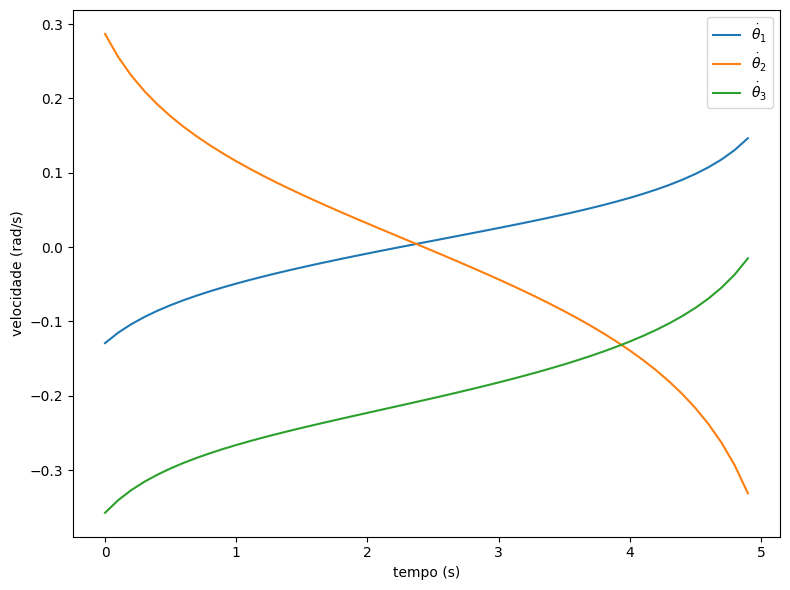

In [ ]:
plt.style.use('default')
plt.figure(figsize=(8, 6))
plt.plot(hist_tempo, hist_velocidade_juntas[:,0], label=r'$\dot{\theta}_1$')
plt.plot(hist_tempo, hist_velocidade_juntas[:,1], label=r'$\dot{\theta}_2$')
plt.plot(hist_tempo, hist_velocidade_juntas[:,2], label=r'$\dot{\theta}_3$')
# plt.title('Velocidade Junta vs Tempo')
plt.xlabel('tempo (s)')
plt.ylabel('velocidade (rad/s)')
plt.legend()
plt.tight_layout()

2.

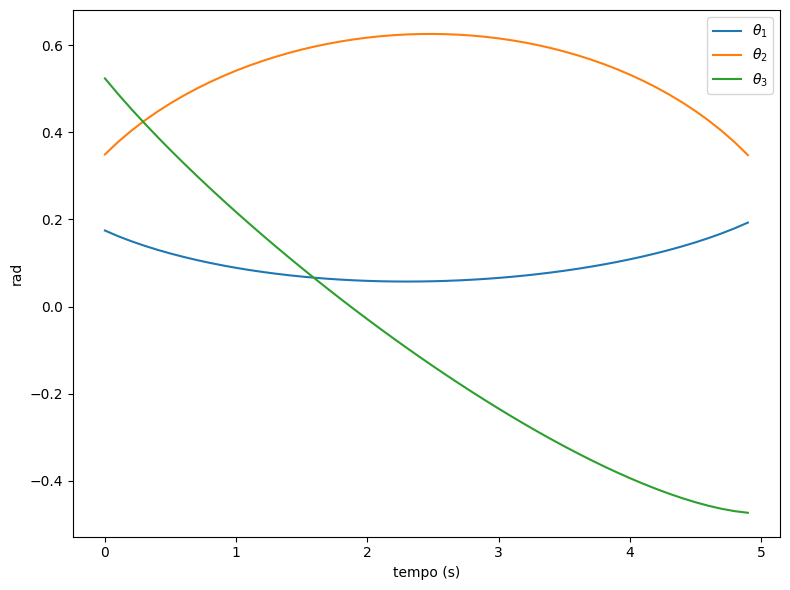

In [ ]:
plt.figure(figsize=(8, 6))
# Convertendo para graus apenas na hora de plotar para ficar mais legível
plt.plot(hist_tempo, hist_angulos[:,0], label=r'$\theta_1$')
plt.plot(hist_tempo, hist_angulos[:,1], label=r'$\theta_2$')
plt.plot(hist_tempo, hist_angulos[:,2], label=r'$\theta_3$')
# plt.title('Ângulo Junta vs Tempo')
plt.xlabel('tempo (s)')
plt.ylabel('rad')
plt.legend()
plt.tight_layout()

3.

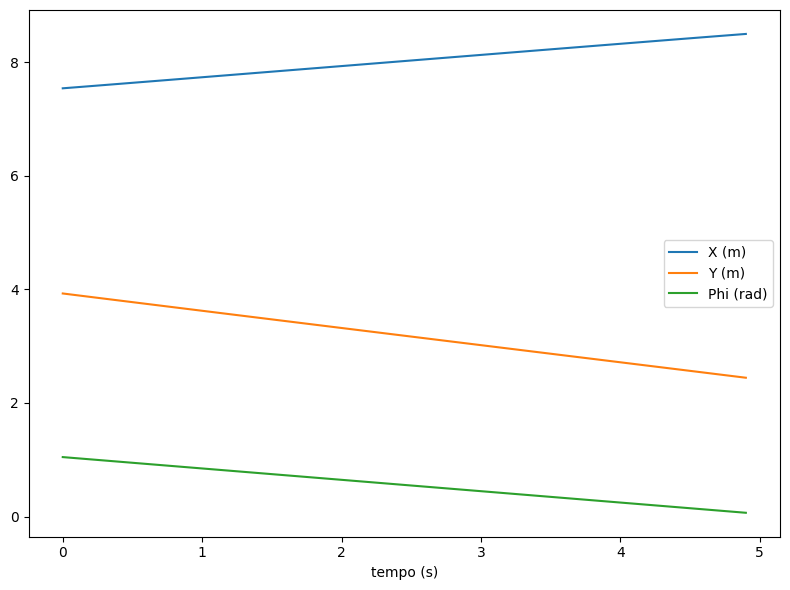

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(hist_tempo, hist_posicao_cartesiana[:,0], label='X (m)')
plt.plot(hist_tempo, hist_posicao_cartesiana[:,1], label='Y (m)')
plt.plot(hist_tempo, hist_posicao_cartesiana[:,2], label='Phi (rad)')
# plt.title('Posição cartesiana')
plt.xlabel('tempo (s)')
# plt.ylabel('Posição / Orientação')
plt.legend()
plt.tight_layout()

4.

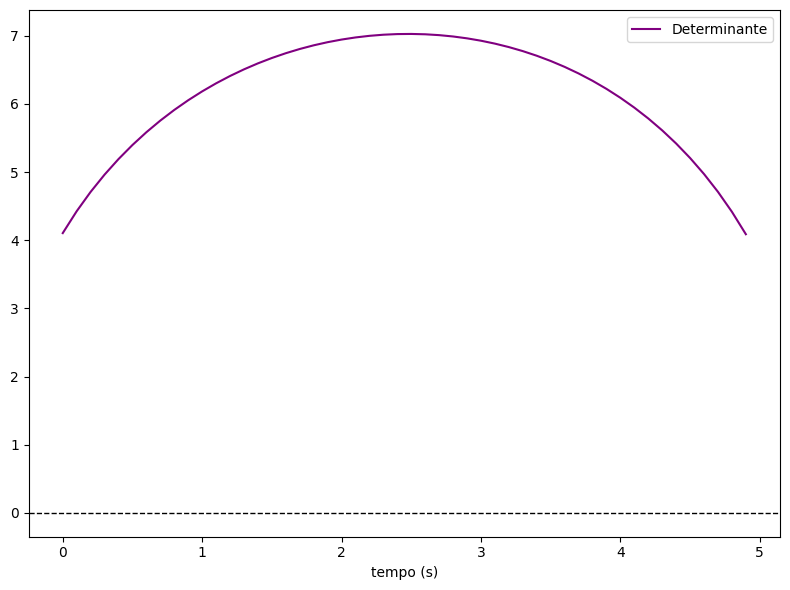

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(hist_tempo, hist_det_jacobiano, color='purple', label='Determinante')
# plt.title('4. Determinante')
plt.xlabel('tempo (s)')
# plt.ylabel('Valor do Determinante')
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Linha de referência no zero
plt.legend()
plt.tight_layout()

5.

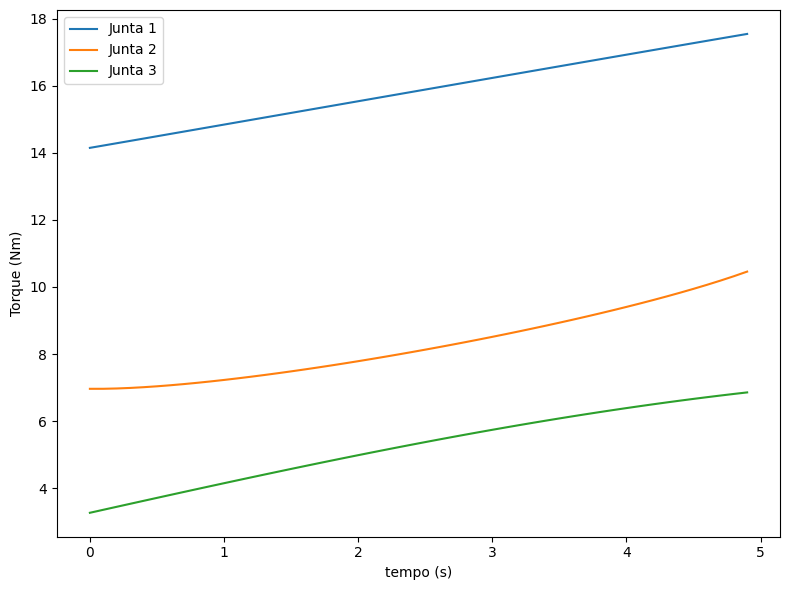

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(hist_tempo, hist_torques[:,0], label='Junta 1')
plt.plot(hist_tempo, hist_torques[:,1], label='Junta 2')
plt.plot(hist_tempo, hist_torques[:,2], label='Junta 3')
# plt.title('5. Torques')
plt.xlabel('tempo (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.tight_layout()

## Item b)

Preparativos para a animação

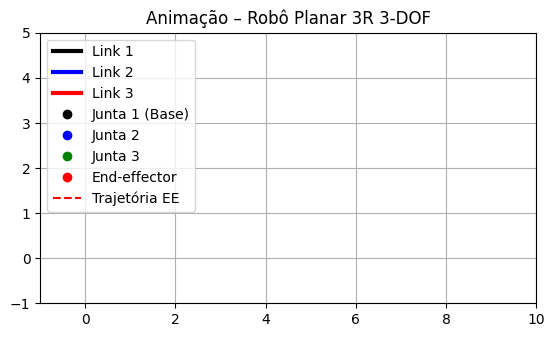

In [ ]:
# Animação do movimento simulado
# Criação do gráfico em branco
fig, ax = plt.subplots()
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title("Animação – Robô Planar 3R 3-DOF")

# Elos
link1, = ax.plot([], [], 'k-', linewidth=3, label='Link 1')
link2, = ax.plot([], [], 'b-', linewidth=3, label='Link 2')
link3, = ax.plot([], [], 'r-', linewidth=3, label='Link 3')

# Juntas
joint1, = ax.plot([], [], 'ko', markersize=6, label='Junta 1 (Base)')
joint2, = ax.plot([], [], 'bo', markersize=6, label='Junta 2')
joint3, = ax.plot([], [], 'go', markersize=6, label='Junta 3')
joint_ee, = ax.plot([], [], 'ro', markersize=6, label='End-effector')

# Trajetória do end-effector
traj_ee, = ax.plot([], [], 'r--', linewidth=1.5, label='Trajetória EE')
traj_x = []
traj_y = []

ax.legend(loc='upper left')

def init():
  for obj in [link1, link2, link3, joint1, joint2, joint3, joint_ee, traj_ee]:
      obj.set_data([], [])
  traj_x.clear()
  traj_y.clear()
  return (link1, link2, link3, joint1, joint2, joint3, joint_ee, traj_ee)

def update(frame): # Atualiza as imagens/frames da animação
  th1, th2, th3 = hist_angulos[frame]
  # senos e cossenos
  s1 = np.sin(th1)
  c1 = np.cos(th1)
  s12 = np.sin(th1 + th2)
  c12 = np.cos(th1 + th2)
  s123 = np.sin(th1 + th2 + th3)
  c123 = np.cos(th1 + th2 + th3)

  # Posição das juntas
  x0, y0 = 0.0, 0.0 # Junta 1/ Base
  x1, y1 = L1*c1, L1*s1 # Junta 2
  x2, y2 = x1 + L2*c12, y1 + L2*s12 # Junta 3
  x3, y3 = x2 + L3*c123, y2 + L3*s123 # end-effector

  # Atualiza os elos
  link1.set_data([x0, x1], [y0, y1])
  link2.set_data([x1, x2], [y1, y2])
  link3.set_data([x2, x3], [y2, y3])

  # Atualiza as juntas
  joint1.set_data([x0], [y0])
  joint2.set_data([x1], [y1])
  joint3.set_data([x2], [y2])
  joint_ee.set_data([x3], [y3])

  # Atualiza a trajetória do end-effector
  traj_x.append(x3)
  traj_y.append(y3)
  traj_ee.set_data(traj_x, traj_y)

  ax.set_xlabel(f"Tempo = {hist_tempo[frame]:.2f} s")

  return (link1, link2, link3, joint1, joint2, joint3, joint_ee)

In [ ]:
# Criando a animação
ani = FuncAnimation(
    fig,
    update,
    frames=len(hist_tempo),
    init_func=init,
    interval=100,
    blit=False)
HTML(ani.to_jshtml())

Execute a célula a seguir apenas se quiser baixar o vídeo da animação

In [ ]:
# salvar a animação em .mp4
writer = FFMpegWriter(
    fps=10,
    metadata=dict(artist='Matheus'),
    bitrate=1800)

ani.save("robo_planar_3R.mp4", writer=writer)
files.download("robo_planar_3R.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Comparação dos resultados de J para os conjuntos de ângulo inicial e final

In [ ]:
# Criando um robô planar 3R da roboticstoolbox
rrr_Robot = DHRobot([RevoluteDH(a=L1), RevoluteDH(a=L2), RevoluteDH(a=L3)], name = "planar_3R")

# Conferindo os resultado de J inicial e final
tht_ini = hist_angulos[0]
tht_fin = hist_angulos[-1]
J_manual_ini = hist_jacobiano[0]
J_manual_fin = hist_jacobiano[-1]
J_lib_ini = rrr_Robot.jacob0(tht_ini)[:3,:]
J_lib_fin = rrr_Robot.jacob0(tht_fin)[:3,:]

print("=== CONFIGURAÇÃO INICIAL ===")
print("Jacobiano manual:\n", J_manual_ini)
print("Jacobiano toolbox:\n", J_lib_ini)
print("\nDiferença:\n", J_manual_ini - J_lib_ini)

print("\n=== CONFIGURAÇÃO FINAL ===")
print("Jacobiano manual:\n", J_manual_fin)
print("Jacobiano toolbox:\n", J_lib_fin)
print("\nDiferença:\n", J_manual_fin - J_lib_fin)


=== CONFIGURAÇÃO INICIAL ===
Jacobiano manual:
 [[-3.92664352 -3.23205081 -1.73205081]
 [ 7.53730722  3.59807621  1.        ]
 [ 1.          1.          1.        ]]
Jacobiano toolbox:
 [[-3.92664352 -3.23205081 -1.73205081]
 [ 7.53730722  3.59807621  1.        ]
 [ 0.          0.          0.        ]]

Diferença:
 [[-4.4408921e-16  0.0000000e+00  0.0000000e+00]
 [ 8.8817842e-16 -4.4408921e-16  0.0000000e+00]
 [ 1.0000000e+00  1.0000000e+00  1.0000000e+00]]

=== CONFIGURAÇÃO FINAL ===
Jacobiano manual:
 [[-2.44375227 -1.67760819 -0.13429398]
 [ 8.49401113  4.56806879  1.99548619]
 [ 1.          1.          1.        ]]
Jacobiano toolbox:
 [[-2.44375227 -1.67760819 -0.13429398]
 [ 8.49401113  4.56806879  1.99548619]
 [ 0.          0.          0.        ]]

Diferença:
 [[-1.33226763e-15 -4.44089210e-16 -8.32667268e-17]
 [ 1.77635684e-15  0.00000000e+00  2.22044605e-16]
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00]]
